# Pressure calibration quickstart

This notebook turns measured MgO unit-cell volumes and temperatures into
pressures using the Tange et al. (2009) pressure scale bundled with Peritheos.
It also checks the inverse calculation, respects the published validity
envelope, and propagates measurement and parameter uncertainty.

The public catalog boundary uses conventional-cell volume in
$\mathrm{\mathring{A}^3}$, temperature in K, and pressure in GPa. Peritheos
performs the conversion required by the thermal model internally.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from peritheos import get_eos_record

plt.style.use("seaborn-v0_8-whitegrid")

mgo = get_eos_record("mgo_b1_tange_2009_vinet")
print(f"Record: {mgo.identifier}")
print(f"Source: {mgo.reference.authors} ({mgo.reference.year})")
print(f"DOI: {mgo.reference.doi}")
print(f"Validity: {mgo.validity}")

Record: mgo_b1_tange_2009_vinet
Source: Y. Tange, Y. Nishihara, and T. Tsuchiya (2009)
DOI: 10.1029/2008JB005813
Validity: ValidityRange(pressure_gpa=(0.0, 196.0), temperature_k=(300.0, 3700.0), volume_ratio=(0.652, 1.15), notes=('Marginal envelope of pressure-scale-free data in Table 1; it is not a rectangular joint domain.', 'Table 5 extends calculations to 4000 K, but values outside the data envelope are extrapolations.'))


## Calculate pressure from measured states

NumPy arrays are accepted directly. Here every volume is paired with the
temperature in the same row. The calculation is valid only if the state lies
inside the record's source-derived envelope.

In [2]:
volumes = np.array([69.0, 65.0, 60.0])
temperatures = np.array([1200.0, 1800.0, 2500.0])

inside = mgo.within_validity(volumes, temperatures)
pressures = mgo.pressure(volumes, temperatures)

print(" volume (A^3)   T (K)   pressure (GPa)   valid")
for volume, temperature, pressure, valid in zip(
    volumes, temperatures, pressures, inside
):
    print(f" {volume:10.3f} {temperature:7.0f} {pressure:16.3f}   {valid}")

 volume (A^3)   T (K)   pressure (GPa)   valid
     69.000    1200           20.532   True
     65.000    1800           39.615   True
     60.000    2500           70.937   True


## Verify pressure-volume inversion

Recovering the measured volumes from the calculated pressures is a useful
unit and reference-state check. It should agree to numerical precision.

In [3]:
recovered_volumes = mgo.volume(pressures, temperatures)
errors = recovered_volumes - volumes

print("Recovered volumes:", recovered_volumes)
print("Maximum absolute round-trip error:", np.max(np.abs(errors)), "A^3")
assert np.allclose(recovered_volumes, volumes, atol=1e-8)

Recovered volumes: [69. 65. 60.]
Maximum absolute round-trip error: 3.694822225952521e-13 A^3


## Plot several isotherms

The separation between these curves is the thermal-pressure contribution.
The plotted range stays within the record's volume and pressure envelope; the
envelope is not a claim that every combination in the surrounding rectangle
was directly measured.

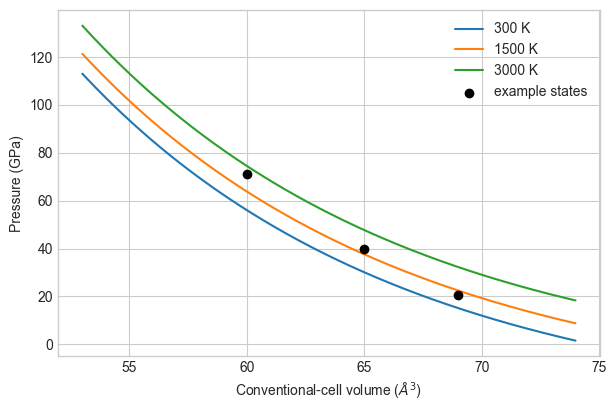

In [4]:
volume_curve = np.linspace(53.0, 74.0, 250)

fig, ax = plt.subplots(figsize=(7.0, 4.5))
for temperature in (300.0, 1500.0, 3000.0):
    ax.plot(
        volume_curve,
        mgo.pressure(volume_curve, temperature),
        label=f"{temperature:.0f} K",
    )

ax.scatter(volumes, pressures, color="black", zorder=3, label="example states")
ax.set(xlabel=r"Conventional-cell volume ($\AA^3$)", ylabel="Pressure (GPa)")
ax.legend()
plt.show()

## Propagate uncertainty

The source reports parameter errors but no parameter covariance. Peritheos
therefore treats those parameter errors as independent and records that
assumption. The measured volume and temperature errors below are also treated
as independent.

In [5]:
prediction = mgo.pressure_with_uncertainty(
    volume=60.0,
    temperature=2000.0,
    volume_sigma=0.02,
    temperature_sigma=20.0,
)

print(f"Pressure: {prediction.value:.3f} +/- {prediction.standard_error:.3f} GPa")
print(
    f"{prediction.confidence:.0%} pointwise interval: "
    f"[{prediction.lower:.3f}, {prediction.upper:.3f}] GPa"
)
print("Assumptions:")
for assumption in prediction.assumptions:
    print(f"- {assumption}")

Pressure: 67.374 +/- 0.327 GPa
95% pointwise interval: [66.733, 68.014] GPa
Assumptions:
- parameter errors treated as mutually independent
- local linear (delta-method) uncertainty propagation
- state-variable errors treated as independent


## Check before extrapolating

`within_validity` is the non-raising way to screen proposed states. Normal
calculations check validity by default and reject states outside the published
envelope. Disabling that check is an explicit extrapolation and should be
reported as such.

In [6]:
candidate_temperatures = np.array([300.0, 2000.0, 4000.0])
candidate_volumes = np.full(candidate_temperatures.shape, 60.0)

for temperature, valid in zip(
    candidate_temperatures,
    mgo.within_validity(candidate_volumes, candidate_temperatures),
):
    print(f"V=60.0 A^3, T={temperature:4.0f} K: valid={valid}")

V=60.0 A^3, T= 300 K: valid=True
V=60.0 A^3, T=2000 K: valid=True
V=60.0 A^3, T=4000 K: valid=False


## Takeaways

1. Use an explicit literature record rather than an unnamed collection of
   coefficients.
2. Supply conventional-cell volume, K, and GPa at the catalog boundary.
3. Verify inversion when establishing a new analysis pipeline.
4. Preserve the validity decision and statistical assumptions with the
   reported pressure.